In [1]:
!pip install -q youtube-transcript-api langchain langchain-core langchain-groq faiss-cpu

In [2]:
from google.colab import userdata
GROQ_API_KEY=userdata.get('GROQ_API_KEY')

In [3]:
from langchain_groq import ChatGroq

llm=ChatGroq(
    model='openai/gpt-oss-20b',
    api_key=GROQ_API_KEY
)

In [4]:
!pip install -q langchain-text-splitters

In [5]:
!pip install -q langchain-community

In [6]:
from youtube_transcript_api import YouTubeTranscriptApi
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

/tmp/ipykernel_4327/2492229892.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [8]:
video_id = "Nb-8ontjFF4"

ytt_api = YouTubeTranscriptApi()

transcript = ytt_api.fetch(
    video_id,
    languages=["en"]
)

print(transcript)

FetchedTranscript(snippets=[FetchedTranscriptSnippet(text='Cloud, GPT, and Gemini have a lot of', start=0.16, duration=5.36), FetchedTranscriptSnippet(text='public knowledge, but they know nothing', start=3.6, duration=4.959), FetchedTranscriptSnippet(text='about your own company specific data.', start=5.52, duration=5.44), FetchedTranscriptSnippet(text="That's where rack architectures come in.", start=8.559, duration=4.401), FetchedTranscriptSnippet(text="You've most likely heard the basic", start=10.96, duration=5.12), FetchedTranscriptSnippet(text='recipe before. You take your documents,', start=12.96, duration=5.68), FetchedTranscriptSnippet(text='you parse them, you split them into', start=16.08, duration=4.959), FetchedTranscriptSnippet(text='different chunks, and then you calculate', start=18.64, duration=5.6), FetchedTranscriptSnippet(text='embeddings to basically unlock the', start=21.039, duration=6.32), FetchedTranscriptSnippet(text='semantic search on the retrieval time to'

In [19]:
transcript=" ".join(x.text for x in transcript)
print(transcript)

Cloud, GPT, and Gemini have a lot of public knowledge, but they know nothing about your own company specific data. That's where rack architectures come in. You've most likely heard the basic recipe before. You take your documents, you parse them, you split them into different chunks, and then you calculate embeddings to basically unlock the semantic search on the retrieval time to feed your LLM's context windows with the right knowledge snippets with the right chunks from your internal documents to get grounded answers for your agents. This is not very new, but things changed in the last 3 years. And also data bricks introduced recently a lot of new capabilities to basically simplify and to improve the end-to-end life cycle. There is now semantic parsing and chunking available. And there are many things you can also improve on the retrieval side of things with hybrid search and proper reranking. Therefore, today I'm going to walk you through the end to end setup to build a proper rack 

# Indexing(Text Splitting)

In [20]:
splitter=RecursiveCharacterTextSplitter(
    chunk_size=1000,chunk_overlap=200
)
chunks=splitter.create_documents([transcript])

In [23]:
len(chunks)

46

# Embeddings

In [25]:
!pip install -q langchain-huggingface sentence-transformers

In [26]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#Vector Store

In [27]:
vector_store=FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

#Retriever

In [30]:
retriever=vector_store.as_retriever(
    search_type='similarity',
    search_kwargs={"k":4}
)

In [31]:
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7f5432285940>, search_kwargs={'k': 4})

In [34]:
from rich import print
print(retriever.invoke("What is Smart Chunking?"))

[
    Document(
        id='8ba0f2fc-1ea2-4923-b1d8-f07420fb0428',
        metadata={},
        page_content="is doing. So essentially it is splitting the document into different chunks. Right? Again 
this is what you would want to do because you want to only like retrieve and infuse into your LLM's context windows
the relevant pieces of text. Therefore, you typically split things into chunks. But then always the question is how
to split my document into the different chunks. And the AI prep search function is using again an agentp powered 
way of working similar to the AI parse document. So it is basically automatically doing the chunking in let's say a
logical way meaning it's for example not splitting this table here into two different chunks right because one very
like simple chunking strategy would be just to split all the time after 500 characters for example. If you do it 
that way, you would most likely have situations where you, for example, split a super important part into two. You 
could split a table into two and so on. So the question is always how to properly chunk into logical"
    ),
    Document(
        id='50f4b6de-be54-455b-b970-0d81e348e2f0',
        metadata={},
        page_content="it's maybe not enough to just keep that description and text of that image but also to keep a
reference to the actual image so that later on downstream we can just read that image in and we can maybe have a 
more powerful LLM try to reason about what is actually in there. Awesome. Now putting it all together in one create
table statement it would look the following. So we are creating our silver table with the chunked manuals. Right? 
As we are now like parsing and chunking it makes sense to logically put it into the silver schema here. So not in 
the browse anymore. We call it manuals chunked and then we apply all of that. This one is anyways the default. we 
can leave it out. But all the rest basically is what we just discussed. We do the parsing. We add the image output.
Then we use that to do the AI prep search. We are further like exploding that and create proper columns out of it. 
And you see here I added one more step to also basically have the information about the image output"
    ),
    Document(
        id='8f5e5cf4-88e1-4732-b517-311635b8df22',
        metadata={},
        page_content="most likely have situations where you, for example, split a super important part into two. 
You could split a table into two and so on. So the question is always how to properly chunk into logical pieces. 
And the approach from data bricks using this AI prep search is basically using AI to come up with proper chunks. 
This also means they are not necessarily of the same size always. Like you can see over here, this one is a bit 
longer. Again, it did not want to split a table in between, which makes sense. And this is the chunk to retrieve, 
right? But there is also the chunk to embed. And now it gets interesting. So apart from only like having this 
functionality within the AI prep search of splitting things logically into different chunks or semantically into 
different chunks. It's also distinguishing between what we actually embed and what we retrieve. What we retrieve is
always coming directly from our documents. So all of this text here is one to one exactly somewhere in our 
document."
    ),
    Document(
        id='08fe42cf-6844-45ec-9b27-b9045d8da547',
        metadata={},
        page_content="would not necessarily have for each and every document type. But in my case, as it's about 
like elevators, it makes sense to have this additional information here. And this is also what the AI prep search 
came up with automatically. So I did not specify that I would need to have this additional metadata information 
what kind of equipment this chunk is about but instead the function came up with it by itself and then you see at 
the bottom here we have the actual content. This is exactly pasting um what we have here on the ch

In [35]:
prompt=PromptTemplate(
    template="""You are a helpful assistant.
      Answer ONLY from the provided transcript context.
      If the context is insufficient, just say you don't know.

      {context}
      Question: {question}"""
)
print(prompt)

PromptTemplate(
    input_variables=['context', 'question'],
    input_types={},
    partial_variables={},
    template="You are a helpful assistant.\n      Answer ONLY from the provided transcript context.\n      If the 
context is insufficient, just say you don't know.\n\n      {context}\n      Question: {question}"
)

In [36]:
question="What is Smart Chunking?"

retriever_docs=retriever.invoke(question)
print(retriever_docs)

[
    Document(
        id='8ba0f2fc-1ea2-4923-b1d8-f07420fb0428',
        metadata={},
        page_content="is doing. So essentially it is splitting the document into different chunks. Right? Again 
this is what you would want to do because you want to only like retrieve and infuse into your LLM's context windows
the relevant pieces of text. Therefore, you typically split things into chunks. But then always the question is how
to split my document into the different chunks. And the AI prep search function is using again an agentp powered 
way of working similar to the AI parse document. So it is basically automatically doing the chunking in let's say a
logical way meaning it's for example not splitting this table here into two different chunks right because one very
like simple chunking strategy would be just to split all the time after 500 characters for example. If you do it 
that way, you would most likely have situations where you, for example, split a super important part into two. You 
could split a table into two and so on. So the question is always how to properly chunk into logical"
    ),
    Document(
        id='50f4b6de-be54-455b-b970-0d81e348e2f0',
        metadata={},
        page_content="it's maybe not enough to just keep that description and text of that image but also to keep a
reference to the actual image so that later on downstream we can just read that image in and we can maybe have a 
more powerful LLM try to reason about what is actually in there. Awesome. Now putting it all together in one create
table statement it would look the following. So we are creating our silver table with the chunked manuals. Right? 
As we are now like parsing and chunking it makes sense to logically put it into the silver schema here. So not in 
the browse anymore. We call it manuals chunked and then we apply all of that. This one is anyways the default. we 
can leave it out. But all the rest basically is what we just discussed. We do the parsing. We add the image output.
Then we use that to do the AI prep search. We are further like exploding that and create proper columns out of it. 
And you see here I added one more step to also basically have the information about the image output"
    ),
    Document(
        id='8f5e5cf4-88e1-4732-b517-311635b8df22',
        metadata={},
        page_content="most likely have situations where you, for example, split a super important part into two. 
You could split a table into two and so on. So the question is always how to properly chunk into logical pieces. 
And the approach from data bricks using this AI prep search is basically using AI to come up with proper chunks. 
This also means they are not necessarily of the same size always. Like you can see over here, this one is a bit 
longer. Again, it did not want to split a table in between, which makes sense. And this is the chunk to retrieve, 
right? But there is also the chunk to embed. And now it gets interesting. So apart from only like having this 
functionality within the AI prep search of splitting things logically into different chunks or semantically into 
different chunks. It's also distinguishing between what we actually embed and what we retrieve. What we retrieve is
always coming directly from our documents. So all of this text here is one to one exactly somewhere in our 
document."
    ),
    Document(
        id='08fe42cf-6844-45ec-9b27-b9045d8da547',
        metadata={},
        page_content="would not necessarily have for each and every document type. But in my case, as it's about 
like elevators, it makes sense to have this additional information here. And this is also what the AI prep search 
came up with automatically. So I did not specify that I would need to have this additional metadata information 
what kind of equipment this chunk is about but instead the function came up with it by itself and then you see at 
the bottom here we have the actual content. This is exactly pasting um what we have here on the ch

In [37]:
context="\n\n".join(x.page_content for x in retriever_docs)
print(context)

is doing. So essentially it is splitting the document into different chunks. Right? Again this is what you would 
want to do because you want to only like retrieve and infuse into your LLM's context windows the relevant pieces of
text. Therefore, you typically split things into chunks. But then always the question is how to split my document 
into the different chunks. And the AI prep search function is using again an agentp powered way of working similar 
to the AI parse document. So it is basically automatically doing the chunking in let's say a logical way meaning 
it's for example not splitting this table here into two different chunks right because one very like simple 
chunking strategy would be just to split all the time after 500 characters for example. If you do it that way, you 
would most likely have situations where you, for example, split a super important part into two. You could split a 
table into two and so on. So the question is always how to properly chunk into logical

it's maybe not enough to just keep that description and text of that image but also to keep a reference to the 
actual image so that later on downstream we can just read that image in and we can maybe have a more powerful LLM 
try to reason about what is actually in there. Awesome. Now putting it all together in one create table statement 
it would look the following. So we are creating our silver table with the chunked manuals. Right? As we are now 
like parsing and chunking it makes sense to logically put it into the silver schema here. So not in the browse 
anymore. We call it manuals chunked and then we apply all of that. This one is anyways the default. we can leave it
out. But all the rest basically is what we just discussed. We do the parsing. We add the image output. Then we use 
that to do the AI prep search. We are further like exploding that and create proper columns out of it. And you see 
here I added one more step to also basically have the information about the image output

most likely have situations where you, for example, split a super important part into two. You could split a table 
into two and so on. So the question is always how to properly chunk into logical pieces. And the approach from data
bricks using this AI prep search is basically using AI to come up with proper chunks. This also means they are not 
necessarily of the same size always. Like you can see over here, this one is a bit longer. Again, it did not want 
to split a table in between, which makes sense. And this is the chunk to retrieve, right? But there is also the 
chunk to embed. And now it gets interesting. So apart from only like having this functionality within the AI prep 
search of splitting things logically into different chunks or semantically into different chunks. It's also 
distinguishing between what we actually embed and what we retrieve. What we retrieve is always coming directly from
our documents. So all of this text here is one to one exactly somewhere in our document.

would not necessarily have for each and every document type. But in my case, as it's about like elevators, it makes
sense to have this additional information here. And this is also what the AI prep search came up with 
automatically. So I did not specify that I would need to have this additional metadata information what kind of 
equipment this chunk is about but instead the function came up with it by itself and then you see at the bottom 
here we have the actual content. This is exactly pasting um what we have here on the chunk to retrieve and we even 
get here two more things. So first of all we get as we have in this chunk a table we get a table summary. So if you
have tables in your chunks, it's also creating summaries of the tables which can also highly improve the retrieval 
quality and it also even generating automatically questions that could be answered by this chunk here. And later if
we ask something similar to that, it's very likely that our retrieval part w

In [38]:
final_prompt=prompt.invoke({
    "context":context,
    "question":question
})

In [39]:
result=llm.invoke(final_prompt)

In [42]:
print(result.content)

**Smart Chunking** is an AI‑driven technique for splitting a document into logical, semantically coherent pieces 
rather than using a fixed character or token count. It automatically recognizes structural boundaries (e.g., 
tables, headings, sections) and creates chunks that keep related content together, so that important information 
isn’t split in the middle of a table or sentence. This improves both retrieval (exact text match) and embedding 
(semantic relevance) for downstream LLM tasks.

In [43]:
from langchain_core.runnables import RunnableParallel,RunnablePassthrough,RunnableLambda

In [44]:
def formattext(retriever_docs):
  context="\n\n".join(x.page_content for x in retriever_docs )
  return context

In [45]:
parallel_chain=RunnableParallel(
    {
        "context":retriever | RunnableLambda(formattext),
        "question":RunnablePassthrough()
    }
)

In [48]:
parser=StrOutputParser()
chain=parallel_chain | prompt | llm | parser
res=chain.invoke("What is smart Chunking?")

In [50]:
print(res)

**Smart chunking** is an AI‑driven method for breaking a document into logical, semantically meaningful pieces 
instead of just cutting it at fixed character or token limits.  
Key points from the transcript:

- **Logical boundaries** – The AI identifies natural breaks (e.g., end of a paragraph, end of a table, or image 
boundary) and avoids splitting important structures like tables or images across chunks.  
- **Variable size** – Chunks aren’t all the same length; the AI chooses the size that best preserves meaning.  
- **Metadata generation** – For each chunk it can add useful information such as a table summary or automatically 
generated questions, which can improve retrieval quality.  
- **Separate “chunk to retrieve” and “chunk to embed”** – The text that will be returned to the user is taken 
directly from the source (one‑to‑one), while the chunk used for embedding can be a condensed or enriched version.  

In short, smart chunking uses AI to split documents in a way that keeps the content coherent, preserves structure, 
and enriches each piece with helpful metadata for better downstream retrieval and reasoning.

In [51]:
res=chain.invoke("can u summarize the whole vedio?")

In [53]:
print(res)

**Video Summary**

The video walks through the end‑to‑end process of creating a “silver” table that stores chunked technical manuals 
for elevators. The key steps are:

1. **Table Creation**  
   - A single `CREATE TABLE` statement builds the silver schema.  
   - The table holds parsed chunks of the manuals, including text and image references.

2. **Parsing & Chunking**  
   - The raw PDFs are parsed, split into logical sections, and each chunk is enriched with metadata (e.g., page 
number, box coordinates, type of content such as text or figure).

3. **Image Handling**  
   - For each figure, a reference to the actual image is stored.  
   - The parsing step also extracts a textual description of the figure (e.g., “blue diamond with a white arrow”).

4. **AI‑Prep Search**  
   - An AI‑powered step enriches each chunk with additional metadata (equipment type, table summaries, 
automatically generated questions).  
   - This improves search relevance and allows quick extraction of key information.

5. **Similarity Search**  
   - When a user asks a question (e.g., “What about the door panels?”), the system retrieves the most similar chunk
based on the parsed content.

6. **Vision Model Overlay**  
   - After retrieving a chunk that contains a figure, a vision model can be run on the stored image to provide more
detailed visual information that wasn’t captured in the initial text summary.

7. **Result Presentation**  
   - The final output includes the chunk text, figure description, table summaries, and any automatically generated
questions, giving users a comprehensive view of the requested information.

Overall, the video demonstrates how to build a searchable, richly‑annotated database of technical manuals that 
combines text parsing, image referencing, AI‑generated metadata, and vision inference to deliver precise, 
context‑aware answers.

In [54]:
!pip install -q gradio

In [61]:
import gradio as gr
from langchain_huggingface import HuggingFaceEmbeddings

def get_video_summary(video_id, user_question):
    try:
        # Fetch transcript
        ytt_api = YouTubeTranscriptApi()
        transcript_snippets = ytt_api.fetch(video_id, languages=['en'])
        transcript = " ".join(x.text for x in transcript_snippets)

        # Text Splitting
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000,
            chunk_overlap=200
        )
        chunks = splitter.create_documents([transcript])

        # Embeddings
        embeddings=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

        # Vector Store
        vector_store = FAISS.from_documents(
            documents=chunks,
            embedding=embeddings
        )

        # Retriever
        retriever = vector_store.as_retriever(
            search_type='similarity',
            search_kwargs={"k": 4}
        )

        # Prompt template
        prompt = PromptTemplate(
            template="""You are a helpful assistant.
              Answer ONLY from the provided transcript context.
              If the context is insufficient, just say you don't know.

              {context}
              Question: {question}"""
        )

        # Chain definition (reusing llm and parser)
        # parallel_chain and formattext function are already defined
        parallel_chain = RunnableParallel(
            {
                "context": retriever | RunnableLambda(formattext),
                "question": RunnablePassthrough()
            }
        )
        parser = StrOutputParser()
        chain = parallel_chain | prompt | llm | parser

        # Invoke the chain for the user's question
        answer = chain.invoke(user_question)
        return answer
    except Exception as e:
        return f"An error occurred: {e}. Please check the video ID and ensure the transcript is available."


In [63]:

interface = gr.Interface(
    fn=get_video_summary,
    inputs=[
        gr.Textbox(lines=1, placeholder="Enter YouTube Video ID (e.g., Nb-8ontjFF4)", label="YouTube Video ID"),
        gr.Textbox(lines=2, placeholder="Enter your question about the video transcript", label="Question")
    ],
    outputs=gr.Textbox(lines=10, label="Answer"),
    title="YouTube Video QA",
    description="Enter a YouTube video ID and your question to get an answer based on its transcript."
)

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2f1c1bf3302650191f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7862 <> https://2f1c1bf3302650191f.gradio.live


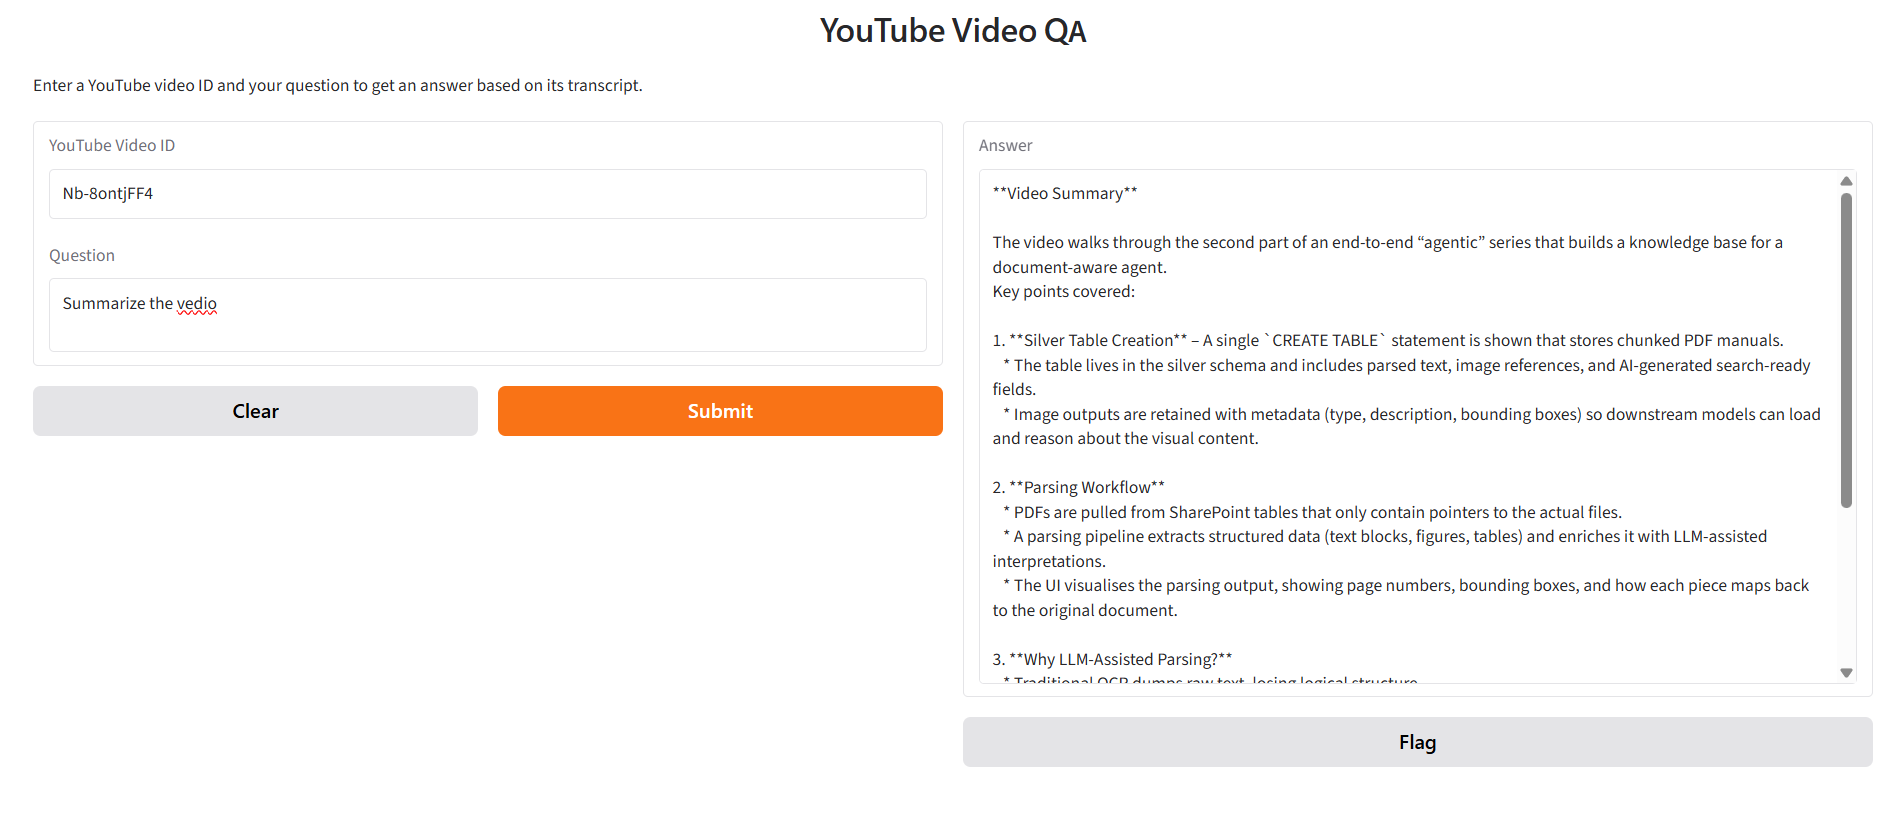